In [4]:
import pandas as pd
import numpy as np
import os

In [ ]:
## Пока не настраивали DVC лучше не выполнять код этой клетки, а просто считать data из dataset.txt

# import zipfile
# from pathlib import Path

# zip_path = Path("data/raw/Toxic Russian Comments.zip")
# extract_dir = Path("data/interim/")

# with zipfile.ZipFile(zip_path, 'r') as z:
#     z.extractall(extract_dir)

In [ ]:
# позаимствовал методы у Даши
def is_mixed_class(row: str) -> bool:
    sep_idx = row.index(" ")
    return len(row[:sep_idx].split(",")) > 1

def define_toxicity_class(row: str) -> str:
    sep_idx = row.index(" ")
    classes = row[:sep_idx].split(",")
    return ",".join([class_name[9:] for class_name in classes])

def extract_message_text(row: str) -> str:
    sep_idx = row.index(" ")
    return row[sep_idx + 1:]

In [ ]:
from pathlib import Path

lines = []
# вставьте корректный путь к файлу
with open(Path("data/interim/dataset.txt"), "r") as file: 
    lines = [line.rstrip() for line in file.readlines()]
data = pd.DataFrame(lines, columns=["raw_text"])
data["mixed_class"] = data["raw_text"].apply(is_mixed_class)
data["toxicity_class"] = data["raw_text"].apply(define_toxicity_class)
data["message_text"] = data["raw_text"].apply(extract_message_text)
data[["message_text", "toxicity_class", "mixed_class"]].describe()

,message_text,toxicity_class,mixed_class
count,248290,248290,248290
unique,248284,8,2
top,расстрелять нахуй,NORMAL,False
freq,2,203685,239957


In [7]:
data.head(10)

,raw_text,mixed_class,toxicity_class,message_text
0,__label__INSULT скотина! что сказать,False,INSULT,скотина! что сказать
1,__label__NORMAL я сегодня проезжала по рабочей...,False,NORMAL,я сегодня проезжала по рабочей и между домами ...
2,__label__NORMAL очередной лохотрон. зачем прид...,False,NORMAL,очередной лохотрон. зачем придумывать очередно...
3,__label__NORMAL ретро дежавю ... сложно понять...,False,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ..."
4,__label__NORMAL а когда мы статус агрогородка ...,False,NORMAL,а когда мы статус агрогородка получили?
5,__label__NORMAL 2 августа поздно вечером нашли...,False,NORMAL,2 августа поздно вечером нашли вот такую потер...
6,__label__NORMAL вчера надыбала новые стикеры #...,False,NORMAL,вчера надыбала новые стикеры #u2a94ec7fabs#
7,"__label__INSULT,__label__THREAT заколоть этого...",True,"INSULT,THREAT",заколоть этого плешивого урода что бы крякнул ...
8,__label__NORMAL а еще на стоянке никто не пров...,False,NORMAL,а еще на стоянке никто не проверяет безопаснос...
9,"__label__NORMAL красота..!! если есть, что пок...",False,NORMAL,"красота..!! если есть, что показать??!! почему..."


In [10]:
len(data[data['toxicity_class'] != 'NORMAL'])/len(data)

0.17964879777679327

In [12]:
print(data['toxicity_class'].unique())

# Считаем количество и долю каждой категории
counts = data['toxicity_class'].value_counts()
proportions = data['toxicity_class'].value_counts(normalize=True)

print("Абсолютные значения:")
print(counts)
print("\nДоли:")
print(proportions)


['INSULT' 'NORMAL' 'INSULT,THREAT' 'INSULT,OBSCENITY' 'OBSCENITY' 'THREAT'
 'OBSCENITY,THREAT' 'INSULT,OBSCENITY,THREAT']
Абсолютные значения:
toxicity_class
NORMAL                     203685
INSULT                      28567
INSULT,THREAT                6317
THREAT                       5460
OBSCENITY                    2245
INSULT,OBSCENITY             1766
INSULT,OBSCENITY,THREAT       176
OBSCENITY,THREAT               74
Name: count, dtype: int64

Доли:
toxicity_class
NORMAL                     0.820351
INSULT                     0.115055
INSULT,THREAT              0.025442
THREAT                     0.021990
OBSCENITY                  0.009042
INSULT,OBSCENITY           0.007113
INSULT,OBSCENITY,THREAT    0.000709
OBSCENITY,THREAT           0.000298
Name: proportion, dtype: float64


In [5]:
data[data['toxicity_class'] == "OBSCENITY,THREAT"]

,raw_text,mixed_class,toxicity_class,message_text
583,"__label__OBSCENITY,__label__THREAT изнасиловат...",True,"OBSCENITY,THREAT",изнасиловать в жопу черенком от снеговой лопат...
825,"__label__OBSCENITY,__label__THREAT его отебать...",True,"OBSCENITY,THREAT",его отебать мало!!!
3098,"__label__OBSCENITY,__label__THREAT ствол ему в...",True,"OBSCENITY,THREAT",ствол ему в очко по самый приклад
5682,"__label__OBSCENITY,__label__THREAT его надо пр...",True,"OBSCENITY,THREAT",его надо просто в зоне ебать!!и по еблу давать
14230,"__label__OBSCENITY,__label__THREAT затолкать в...",True,"OBSCENITY,THREAT",затолкать в задницу по самые помидоры!
...,...,...,...,...
228895,"__label__OBSCENITY,__label__THREAT отебу как о...",True,"OBSCENITY,THREAT",отебу как отстераю
233744,"__label__OBSCENITY,__label__THREAT может тебя ...",True,"OBSCENITY,THREAT",может тебя лучше трахнуть
239145,"__label__OBSCENITY,__label__THREAT в два ствол...",True,"OBSCENITY,THREAT",в два ствола ее разьебать!
245139,"__label__OBSCENITY,__label__THREAT пожизненно ...",True,"OBSCENITY,THREAT","пожизненно должен сидеть, и трахать его должны..."


In [16]:
data[data['toxicity_class'] == "INSULT,THREAT"]

,raw_text,mixed_class,toxicity_class,message_text
7,"__label__INSULT,__label__THREAT заколоть этого...",True,"INSULT,THREAT",заколоть этого плешивого урода что бы крякнул ...
62,"__label__INSULT,__label__THREAT иуда меченная,...",True,"INSULT,THREAT","иуда меченная,сука,повесить его мало."
74,"__label__INSULT,__label__THREAT убить такого м...",True,"INSULT,THREAT",убить такого мало мразь сука отрубить голову б...
105,"__label__INSULT,__label__THREAT уберите эту зе...",True,"INSULT,THREAT",уберите эту зечку с проека.натуральная уголовн...
124,"__label__INSULT,__label__THREAT расстрелять, п...",True,"INSULT,THREAT","расстрелять, падлу!!!"
...,...,...,...,...
248060,"__label__INSULT,__label__THREAT стрелять надо ...",True,"INSULT,THREAT","стрелять надо пидарасов,в месте сусатым тараканом"
248077,"__label__INSULT,__label__THREAT поддерживаю вс...",True,"INSULT,THREAT","поддерживаю всех тех,кто осуждает эти провокац..."
248108,"__label__INSULT,__label__THREAT гнида которую ...",True,"INSULT,THREAT",гнида которую нужно размазать
248192,"__label__INSULT,__label__THREAT урод!!! вот ко...",True,"INSULT,THREAT",урод!!! вот кого надо вешать за яйца вверх ног...


In [17]:
data[data['toxicity_class'] == "INSULT,OBSCENITY"]

,raw_text,mixed_class,toxicity_class,message_text
49,"__label__INSULT,__label__OBSCENITY хрен в жопу...",True,"INSULT,OBSCENITY","хрен в жопу этому мудаку , а не респект"
73,"__label__INSULT,__label__OBSCENITY вот рожа ее...",True,"INSULT,OBSCENITY",вот рожа ее она еблась с узбеками и нарожала
229,"__label__INSULT,__label__OBSCENITY одной рукой...",True,"INSULT,OBSCENITY","одной рукой ,стихи строчил,другой,-хуй,яростно..."
232,"__label__INSULT,__label__OBSCENITY ​наебался в...",True,"INSULT,OBSCENITY",​наебался в жопу насосался обсосал все хуи отл...
481,"__label__INSULT,__label__OBSCENITY путин соси ...",True,"INSULT,OBSCENITY",путин соси хуй тварь
...,...,...,...,...
246985,"__label__INSULT,__label__OBSCENITY ну а что из...",True,"INSULT,OBSCENITY",ну а что изменится ???? эти твари как жрали та...
247149,"__label__INSULT,__label__OBSCENITY хохлоблядь,...",True,"INSULT,OBSCENITY","хохлоблядь, всё сосёшь, не успокоишься ?"
247601,"__label__INSULT,__label__OBSCENITY фэйковая тв...",True,"INSULT,OBSCENITY",фэйковая тварь - приезжай ! я тебя в жопу ебат...
248179,"__label__INSULT,__label__OBSCENITY миша я твой...",True,"INSULT,OBSCENITY",миша я твой род ебал


In [18]:

data[data['toxicity_class'] == "INSULT,OBSCENITY,THREAT"]

,raw_text,mixed_class,toxicity_class,message_text
656,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT",чтобы каждый день как петуха драли )в жопу
3607,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT",я тебя в жопу выебу чурка .
3862,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT",вот там ее и выебу и тебя заодно а за какие де...
4091,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT","посмотрим кто будет жидоской свиньёй,когда мы ..."
4892,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT",я тебя ещё неебал чурка смаж попочку могу и вы...
...,...,...,...,...
243023,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT",жору в жопу выйпу...
245873,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT",тварь ебучая выебать и в очко засунуть
245982,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT","петушок! ты хоть знаешь,что такое крыса? без п..."
246673,"__label__INSULT,__label__OBSCENITY,__label__TH...",True,"INSULT,OBSCENITY,THREAT","этот пидарок,не один хуй заглотит и не подавит..."


In [ ]:
data.loc[data['toxicity_class'] == "OBSCENITY,THREAT", 'toxicity_class'] = "THREAT"
data.loc[data['toxicity_class'] == "INSULT,THREAT", 'toxicity_class'] = "THREAT"
data.loc[data['toxicity_class'] == "INSULT,OBSCENITY", 'toxicity_class'] = "INSULT"

data.loc[data['toxicity_class'] == "INSULT,OBSCENITY", 'toxicity_class'] = "INSULT"


In [16]:
data[data['toxicity_class'] == "INSULT"]['message_text'].sample(20)

128582        воооо даёт курица общипаная. :чтобы ты сдохла
15200     молодцы жители !!!! это ваша земля !!!! , а не...
114551    швыня с пиковым тузом на бляже все козлика ждё...
63511     этот пидорок по имени оленевод, он же по нацио...
242812          ну и че ну и выросла она и ебут ее жабу эту
133228                 таких тварей только могила исправит.
164679                           опущенные белые извращенцы
159071    автор!!! я тваю маму ебал! ана у тебя шалава! ...
38758     эээээ,шваль,нука нака.быдло ебаное.русским при...
61796     жидко срете - группа мы славяне , да и какие в...
121750                    ебать они жирные. легенды жратвы.
199320                                      пуда на хуй это
186518                                       урод конечный!
50612     ну, это, как посмотреть. если смотреть глазами...
27821                                    от дуры прочитала.
209589    петушара трипперный,тебя обоссанного кто-то тр...
112309                                  

In [7]:
print(data['toxicity_class'].unique())

# Считаем количество и долю каждой категории
counts = data['toxicity_class'].value_counts()
proportions = data['toxicity_class'].value_counts(normalize=True)

print("Абсолютные значения:")
print(counts)
print("\nДоли:")
print(proportions)

# может быть сделать obscenety просто insult? 

['INSULT' 'NORMAL' 'THREAT' 'OBSCENITY']
Абсолютные значения:
toxicity_class
NORMAL       203685
INSULT        30333
THREAT        12027
OBSCENITY      2245
Name: count, dtype: int64

Доли:
toxicity_class
NORMAL       0.820351
INSULT       0.122168
THREAT       0.048439
OBSCENITY    0.009042
Name: proportion, dtype: float64


#  Признаки
 
bag of word считает, сколько раз встретилась каждое слово в каждом предложении. получим датасет размера:

\[Количество предложений \* количество слов]

В следующем поле небольшой и понятный пример

In [8]:
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer#, TfidfVectorizer
import pandas as pd

# как выглядят данные 
# data = pd.DataFrame({"message_text": [...], "toxicity_class": [...]})

# токенайзер под тоексичные тексты. МОжно попробовать и другие 
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny-toxicity")


def hf_tokenizer(text):
    # возвращает list[str]
    return tokenizer.tokenize(text)

# 3. Создаем векторизатор
# Можно выбрать CountVectorizer (BoW) или TfidfVectorizer (часто лучше для классификации)
vectorizer = CountVectorizer(
    tokenizer=hf_tokenizer,
    lowercase=False,   # уже lowercased в токенайзере
    max_features=15000 # можно сделать побольше чтобы учитывать редкие слова
)

# 4. Обучаем BoW на всём корпусе
X_bow = vectorizer.fit_transform(data["message_text"])
y = data["toxicity_class"]

# 5. Превращаем в датафрейм (по желанию)
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())
bow_df["toxicity_class"] = y.values

print(bow_df.head())

/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


   !  #  ##0  ##00  ##000  ##01  ##02  ##04  ##1  ##10  ...  №  −  √  ●  《  》  \
0  1  0    0     0      0     0     0     0    0     0  ...  0  0  0  0  0  0   
1  0  0    0     0      0     0     0     0    0     0  ...  0  0  0  0  0  0   
2  1  0    0     0      0     0     0     0    0     0  ...  0  0  0  0  0  0   
3  0  0    0     0      0     0     0     0    0     0  ...  0  0  0  0  0  0   
4  0  0    0     0      0     0     0     0    0     0  ...  0  0  0  0  0  0   

   ー  （  ）  toxicity_class  
0  0  0  0          INSULT  
1  0  0  0          NORMAL  
2  0  0  0          NORMAL  
3  0  0  0          NORMAL  
4  0  0  0          NORMAL  

[5 rows x 11621 columns]


In [39]:
bow_df.shape

(248290, 11621)

In [ ]:
# пример какие есть токены 
import random
print(random.sample(list(bow_df.columns), 20))

['возраст', '##мок', '659', '##2', 'стилю', '576', '##гата', '##lor', '##тик', 'cuts', '##mas', '##rist', '1325', 'гитара', '690', 'барон', '222', 'главный', '##даг', '##лем']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kirilldesatnicenko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


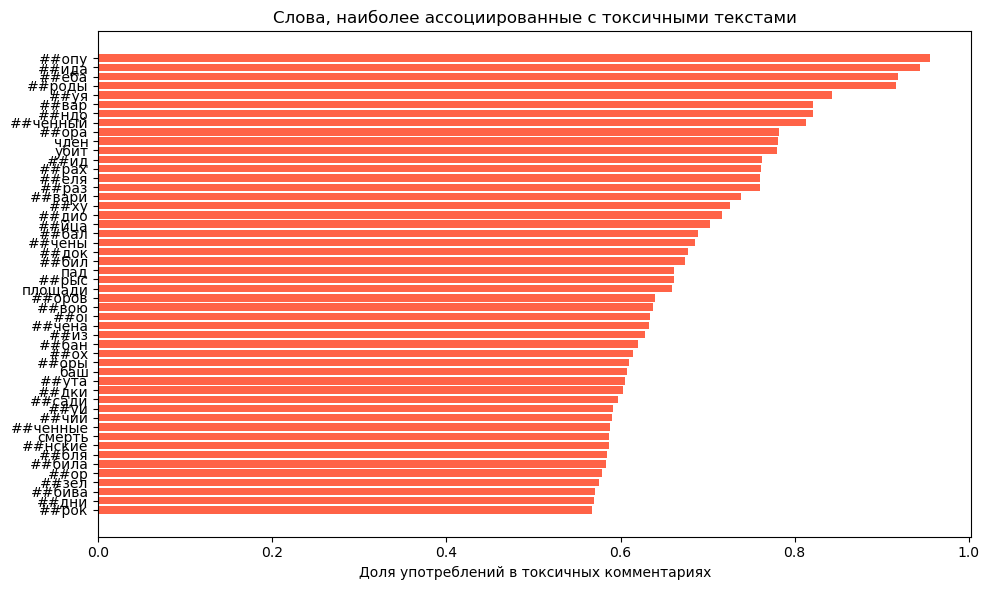

In [46]:
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
russian_stopwords = set(stopwords.words("russian"))

# --- 1. Разделим тексты по классам ---
toxic_df = bow_df[bow_df["toxicity_class"] != "NORMAL"]
normal_df = bow_df[bow_df["toxicity_class"] == "NORMAL"]

# --- 2. Суммируем частоты по каждому слову ---
cols = [c for c in bow_df.columns if c != "toxicity_class"]

toxic_counts = toxic_df[cols].sum()
normal_counts = normal_df[cols].sum()

# --- 3. Соберём всё в один датафрейм ---
word_stats = pd.DataFrame({
    "toxic": toxic_counts,
    "normal": normal_counts
})
word_stats["total"] = word_stats["toxic"] + word_stats["normal"]

# --- 4. Отфильтруем редкие слова и стоп-слова ---
filtered = word_stats[word_stats["total"] >= 200].copy()
filtered = filtered[~filtered.index.isin(russian_stopwords)]

# --- 5. Посчитаем долю токсичных употреблений ---
filtered["toxicity_ratio"] = filtered["toxic"] / (filtered["total"] + 1e-6)

# --- 6. Возьмём топ-30 слов с наибольшей долей токсичности ---
top_words = filtered.sort_values("toxicity_ratio", ascending=False).head(50)

# --- 7. Нарисуем барчарт ---
plt.figure(figsize=(10, 6))
plt.barh(top_words.index, top_words["toxicity_ratio"], color="tomato")
plt.xlabel("Доля употреблений в токсичных комментариях")
plt.title("Слова, наиболее ассоциированные с токсичными текстами")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Простая модель 
Задача тут просто посмотреть какого качества можно добиться если вообще не стараться что-то сделать.

In [ ]:
# простая модель - взвешанная регрессия.
from scipy.sparse import csr_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Подготовим данные ---
df = bow_df.copy()

# бинарная метка: 1 = токсичный, 0 = нормальный
df["label"] = (df["toxicity_class"] != "NORMAL").astype(int)

# отделяем фичи и таргет
X = df.drop(columns=["toxicity_class", "label"])
y = df["label"]

X_sparse = csr_matrix(X.values)

# --- 2. Разделим на train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_sparse, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Обучим логистическую регрессию ---
model = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# --- 4. Оценим качество ---
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# --- 5. Самое интересное — посмотрим, какие слова "тянут" в токсичность ---
feature_weights = pd.DataFrame({
    "word": X.columns,
    "weight": model.coef_[0]
})

# топ 20 токсичных слов (с наибольшим положительным весом)
top_toxic = feature_weights.sort_values("weight", ascending=False).head(20)

# топ 20 нетоксичных слов (с наибольшим отрицательным весом)
top_clean = feature_weights.sort_values("weight").head(20)

print("\n🔴 Сильнее всего ассоциированы с токсичностью:")
print(top_toxic)

print("\n🟢 Сильнее всего ассоциированы с нормальными комментариями:")
print(top_clean)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


              precision    recall  f1-score   support

           0       0.98      0.89      0.93     40737
           1       0.63      0.90      0.74      8921

    accuracy                           0.89     49658
   macro avg       0.80      0.89      0.83     49658
weighted avg       0.91      0.89      0.89     49658

Confusion matrix:
 [[36064  4673]
 [  909  8012]]

🔴 Сильнее всего ассоциированы с токсичностью:
         word    weight
2778     ##ид  2.114640
2779    ##ида  2.111434
4142    ##раз  1.911201
5121     ##ху  1.839164
1771    ##бил  1.816755
2788     ##из  1.815532
2308    ##еба  1.702489
1748    ##бан  1.537923
2406    ##еля  1.521171
2307     ##еб  1.487702
2232    ##дио  1.441088
4947     ##уй  1.426959
4180    ##рах  1.397542
1882    ##вар  1.381583
4330    ##род  1.359571
1885   ##вари  1.258007
8933        е  1.255360
11051      су  1.211809
3358     ##ля  1.205173
4334   ##роды  1.156470

🟢 Сильнее всего ассоциированы с нормальными комментариями:
         wor

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Небольшой вывод
обученная на мешке слов модель очень агрессивно помечает комментарии как токсичные. Поэтому почти все действительно токсичные слова помечены, но очень много не токсичных комментариев помечены как токсичные. Пример 

False Positives часто оказываются:
“блин, как же красиво!” / “ты офигел, в хорошем смысле”
— нейтральные, но с “жаргоном”.

False Negatives — наоборот:
“я тебя найду” / “иди спать, не позорься”
— мягкие, завуалированные угрозы или сарказм, где нет “прямых” ругательств. Видимо на таких примерах модель ничему не научилась, надо на них посмотреть 

In [11]:
#todo настроить комфортный переход от токенов к нормальному тексту и повыводить false positives, false negatives

In [17]:
# простая модель - взвешанная регрессия.
from scipy.sparse import csr_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Подготовим данные ---
df = bow_df.copy()

# бинарная метка: 1 = токсичный, 0 = нормальный
df["label"] = (df["toxicity_class"] != "NORMAL").astype(int)

# отделяем фичи и таргет
X = df.drop(columns=["toxicity_class", "label"])
y = df["label"]

X_sparse = csr_matrix(X.values)

# --- 2. Разделим на train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_sparse, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Обучим логистическую регрессию ---
model = LogisticRegression(
    max_iter=500,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced",
    penalty="l1"
)
model.fit(X_train, y_train)

# --- 4. Оценим качество ---
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# --- 5. Самое интересное — посмотрим, какие слова "тянут" в токсичность ---
feature_weights = pd.DataFrame({
    "word": X.columns,
    "weight": model.coef_[0]
})

# топ 20 токсичных слов (с наибольшим положительным весом)
top_toxic = feature_weights.sort_values("weight", ascending=False).head(20)

# топ 20 нетоксичных слов (с наибольшим отрицательным весом)
top_clean = feature_weights.sort_values("weight").head(20)

print("\n🔴 Сильнее всего ассоциированы с токсичностью:")
print(top_toxic)

print("\n🟢 Сильнее всего ассоциированы с нормальными комментариями:")
print(top_clean)

              precision    recall  f1-score   support

           0       0.98      0.88      0.93     40737
           1       0.63      0.90      0.74      8921

    accuracy                           0.89     49658
   macro avg       0.80      0.89      0.83     49658
weighted avg       0.91      0.89      0.89     49658

Confusion matrix:
 [[36046  4691]
 [  912  8009]]

🔴 Сильнее всего ассоциированы с токсичностью:
         word    weight
2778     ##ид  2.117178
2779    ##ида  2.115124
4142    ##раз  1.914603
5121     ##ху  1.842269
1771    ##бил  1.819219
2788     ##из  1.815966
2308    ##еба  1.704954
1748    ##бан  1.539070
2406    ##еля  1.523578
2307     ##еб  1.488682
2232    ##дио  1.442554
4947     ##уй  1.427364
4180    ##рах  1.397842
1882    ##вар  1.383935
4330    ##род  1.361243
1885   ##вари  1.258451
8933        е  1.255175
11051      су  1.211418
3358     ##ля  1.205767
4334   ##роды  1.157004

🟢 Сильнее всего ассоциированы с нормальными комментариями:
         wor

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
